## Regression Models

#### Adding system path

In [2]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

#### Importing pipeline sources and libraries

In [3]:
import pandas as pd
import numpy as np
from src.data_prep import clean_data, feature_engineering, split_features_target
from src.pipeline import build_preprocessor, build_pipeline
from src.train import stratified_split, train_and_save_model
from src.evaluate import evaluate_model, reg_graph
from src.utils import log_info
from sklearn.linear_model import LinearRegression, Ridge, Lasso

#### Data Preproccessing

In [4]:
log_info("Loading dataset...")
df = pd.read_csv("../data/vehicle_price_prediction.csv")

2025-09-19 16:08:10,712 - INFO - Loading dataset...


In [5]:
log_info(f"Initial dataset shape: {df.shape}")

2025-09-19 16:08:14,686 - INFO - Initial dataset shape: (1000000, 20)


In [6]:
log_info("Cleaning data...")
df = clean_data(df)
df = feature_engineering(df)

log_info(f"Data after cleaning & feature engineering: {df.shape}")

2025-09-19 16:08:18,761 - INFO - Cleaning data...
2025-09-19 16:08:21,759 - INFO - Data after cleaning & feature engineering: (1000000, 22)


In [7]:
X, y = split_features_target(df, target="price_log")

In [8]:
preprocessor = build_preprocessor(X)

#### Train Test split

In [9]:
log_info("Performing stratified train-test split...")
X_train, X_test, y_train, y_test = stratified_split(
    X, y, stratify_col=pd.cut(X["vehicle_age"], bins=[0,5,10,15,20,50])
)

log_info(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

2025-09-19 16:08:28,321 - INFO - Performing stratified train-test split...
2025-09-19 16:08:34,995 - INFO - Train size: (800000, 20), Test size: (200000, 20)


### 1. Linear Regression

In [9]:
model = LinearRegression()
lr_pipeline = build_pipeline(preprocessor, model)

In [10]:
log_info("Training and saving the model...")
train_and_save_model(lr_pipeline, X_train, y_train, model_path="../models/linear_regression_model.pkl")

2025-09-18 18:55:55,400 - INFO - Training and saving the model...


Model saved to ../models/linear_regression_model.pkl


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['mileage', 'engine_hp',
                                                   'owner_count', 'vehicle_age',
                                                   'brand_popularity',
                                                   'price_per_hp',
                                                   'is_luxury_brand',
                                                   'condition_encoded']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['transmission', 'fuel_type',
                                                   'drivetrain', 'body_type',
                                                   'seller_type']),
                                                 ('cat_high',
                                                  Pipeline(steps=[('target_encoder',
                                                                   TargetEncoder())]),
                                                  ['make', 'model', 'trim',
                                                   'exterior_color',
                                                   'interior_color'])])),
                ('model', LinearRegression())])

In [11]:
log_info("Evaluating the model...")
lr_results = evaluate_model(lr_pipeline, X_test, y_test)
log_info(f"Linear Regression Results:\n{lr_results}")

2025-09-18 18:55:59,980 - INFO - Evaluating the model...
2025-09-18 18:56:00,316 - INFO - Linear Regression Results:
       RMSE       MAE        R2      MAPE
0  0.244354  0.184436  0.919291  2.017467


## 2. Lasso Regression

In [12]:
log_info("L1 Regularization with Lasso")
lasso_model = Lasso(alpha=0.1)
lasso_pipeline = build_pipeline(preprocessor, lasso_model)

2025-09-18 18:56:40,574 - INFO - L1 Regularization with Lasso


In [13]:
log_info("Training and saving the Lasso model...")
train_and_save_model(lasso_pipeline, X_train, y_train, model_path="../models/lasso_model.pkl")

2025-09-18 18:57:01,217 - INFO - Training and saving the Lasso model...


Model saved to ../models/lasso_model.pkl


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['mileage', 'engine_hp',
                                                   'owner_count', 'vehicle_age',
                                                   'brand_popularity',
                                                   'price_per_hp',
                                                   'is_luxury_brand',
                                                   'condition_encoded']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['transmission', 'fuel_type',
                                                   'drivetrain', 'body_type',
                                                   'seller_type']),
                                                 ('cat_high',
                                                  Pipeline(steps=[('target_encoder',
                                                                   TargetEncoder())]),
                                                  ['make', 'model', 'trim',
                                                   'exterior_color',
                                                   'interior_color'])])),
                ('model', Lasso(alpha=0.1))])

In [14]:
log_info("Evaluating the model...")
lasso_results = evaluate_model(lasso_pipeline, X_test, y_test)
log_info(f"Lasso Regression Results:\n{lasso_results}")

2025-09-18 18:57:27,043 - INFO - Evaluating the model...
2025-09-18 18:57:27,385 - INFO - Lasso Regression Results:
      RMSE       MAE        R2      MAPE
0  0.33827  0.226306  0.845328  2.560585


In [ ]:
log_info("Hyperparameter Tuning with Lasso Regression")
from sklearn.model_selection import GridSearchCV
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100]}
lasso_grid_search = GridSearchCV(
    lasso_pipeline, 
    param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error')

2025-09-18 18:58:39,718 - INFO - Hyperparameter Tuning with Lasso Regression


In [16]:
train_and_save_model(lasso_grid_search, X_train, y_train, model_path="../models/lasso_model.pkl")

Model saved to ../models/lasso_model.pkl


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['mileage',
                                                                          'engine_hp',
                                                                          'owner_count',
                                                                          'vehicle_age',
                                                                          'brand_popularity',
                                                                          'price_per_hp',
                                                                          'is_luxury_brand',
                                                                          'condition_encoded']),
                                                                        ('cat_low',
                                                                         Pipeline(steps=[('imputer'...
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['transmission',
                                                                          'fuel_type',
                                                                          'drivetrain',
                                                                          'body_type',
                                                                          'seller_type']),
                                                                        ('cat_high',
                                                                         Pipeline(steps=[('target_encoder',
                                                                                          TargetEncoder())]),
                                                                         ['make',
                                                                          'model',
                                                                          'trim',
                                                                          'exterior_color',
                                                                          'interior_color'])])),
                                       ('model', Lasso(alpha=0.1))]),
             param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [23]:
log_info("Evaluating the model after hyperparameter tuning...")
lasso_results = evaluate_model(lasso_grid_search.best_estimator_, X_test, y_test)
log_info(f"Lasso Regression Results after Hyperparameter Tuning:\n{lasso_results}")

2025-09-18 19:07:40,320 - INFO - Evaluating the model after hyperparameter tuning...
2025-09-18 19:07:40,651 - INFO - Lasso Regression Results after Hyperparameter Tuning:
       RMSE      MAE        R2      MAPE
0  0.248881  0.18375  0.916272  2.025379


In [24]:
print(lasso_grid_search.best_params_)
print(f'Lasso Grid Search Best Negative MSE: {lasso_grid_search.best_score_}')

{'model__alpha': 0.01}
Lasso Grid Search Best Negative MSE: -0.0616363618464643


2025-09-19 16:02:38,415 - INFO - Reg plot for lasso predictions


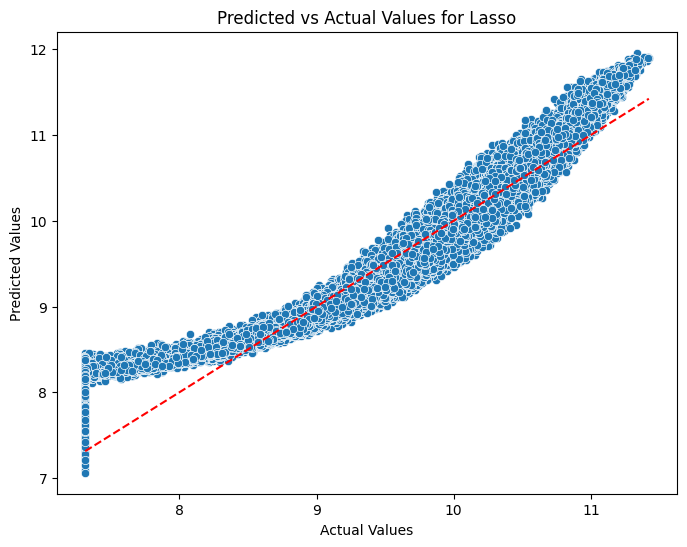

In [44]:
log_info("Reg plot for lasso predictions")
reg_graph(lasso_grid_search.best_estimator_, X_test, y_test)

## 3. Ridge Regression

In [18]:
log_info("L2 Regularization with Ridge")
ridge_model = Ridge(alpha=1.0)
ridge_pipeline = build_pipeline(preprocessor, ridge_model)

2025-09-18 19:04:46,362 - INFO - L2 Regularization with Ridge


In [19]:
log_info("Training and saving the ridge model...")
train_and_save_model(ridge_pipeline, X_train, y_train, model_path="../models/ridge_model.pkl")

2025-09-18 19:04:58,897 - INFO - Training and saving the ridge model...


Model saved to ../models/ridge_model.pkl


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['mileage', 'engine_hp',
                                                   'owner_count', 'vehicle_age',
                                                   'brand_popularity',
                                                   'price_per_hp',
                                                   'is_luxury_brand',
                                                   'condition_encoded']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['transmission', 'fuel_type',
                                                   'drivetrain', 'body_type',
                                                   'seller_type']),
                                                 ('cat_high',
                                                  Pipeline(steps=[('target_encoder',
                                                                   TargetEncoder())]),
                                                  ['make', 'model', 'trim',
                                                   'exterior_color',
                                                   'interior_color'])])),
                ('model', Ridge())])

In [20]:
log_info("Evaluating the ridge model...")
ridge_results = evaluate_model(ridge_pipeline, X_test, y_test)
log_info(f"Ridge Regression Results:\n{ridge_results}")

2025-09-18 19:05:20,605 - INFO - Evaluating the ridge model...
2025-09-18 19:05:20,928 - INFO - Ridge Regression Results:
       RMSE       MAE        R2      MAPE
0  0.244353  0.184434  0.919291  2.017449


In [29]:
log_info("Hyperparameter Tuning with Ridge Regression")
ridge_param_grid = {
    'model__alpha': [0.1, 1.0, 10.0]
}
ridge_grid_search = GridSearchCV(
    ridge_pipeline, 
    ridge_param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error')

2025-09-18 19:11:31,090 - INFO - Hyperparameter Tuning with Ridge Regression


In [30]:
log_info("Training and saving the ridge model...")
train_and_save_model(ridge_grid_search, X_train, y_train, model_path="../models/ridge_model.pkl")

2025-09-18 19:11:33,812 - INFO - Training and saving the ridge model...


Model saved to ../models/ridge_model.pkl


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['mileage',
                                                                          'engine_hp',
                                                                          'owner_count',
                                                                          'vehicle_age',
                                                                          'brand_popularity',
                                                                          'price_per_hp',
                                                                          'is_luxury_brand',
                                                                          'condition_encoded']),
                                                                        ('cat_low',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['transmission',
                                                                          'fuel_type',
                                                                          'drivetrain',
                                                                          'body_type',
                                                                          'seller_type']),
                                                                        ('cat_high',
                                                                         Pipeline(steps=[('target_encoder',
                                                                                          TargetEncoder())]),
                                                                         ['make',
                                                                          'model',
                                                                          'trim',
                                                                          'exterior_color',
                                                                          'interior_color'])])),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.1, 1.0, 10.0]},
             scoring='neg_mean_squared_error')

In [31]:
log_info("Evaluating the model after hyperparameter tuning...")
ridge_results = evaluate_model(ridge_grid_search.best_estimator_, X_test, y_test)
log_info(f"Ridge Regression Results after Hyperparameter Tuning:\n{ridge_results}")

2025-09-18 19:13:47,603 - INFO - Evaluating the model after hyperparameter tuning...
2025-09-18 19:13:47,929 - INFO - Ridge Regression Results after Hyperparameter Tuning:
       RMSE       MAE        R2      MAPE
0  0.244354  0.184436  0.919291  2.017465


2025-09-19 16:02:09,377 - INFO - Reg plot for ridge predictions


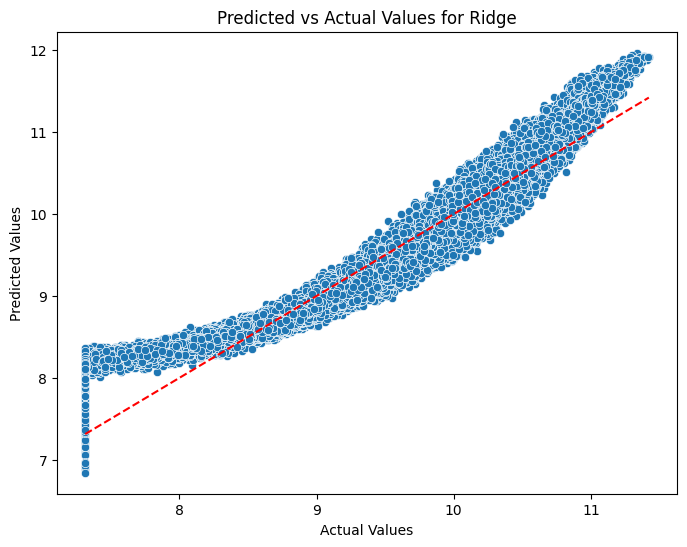

In [43]:
log_info("Reg plot for ridge predictions")
reg_graph(ridge_grid_search.best_estimator_, X_test, y_test)

## Decision Tree Regreesor

In [32]:
log_info("Decision Tree Regressor")
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)

2025-09-19 15:53:03,832 - INFO - Decision Tree Regressor


In [33]:
dt_pipeline = build_pipeline(preprocessor, dt_model)
log_info("Training and saving the Decision Tree model...")
train_and_save_model(dt_pipeline, X_train, y_train, model_path="../models/decision_tree_model.pkl")

2025-09-19 15:53:33,565 - INFO - Training and saving the Decision Tree model...


Model saved to ../models/decision_tree_model.pkl


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['mileage', 'engine_hp',
                                                   'owner_count', 'vehicle_age',
                                                   'brand_popularity',
                                                   'price_per_hp',
                                                   'is_luxury_brand',
                                                   'condition_encoded']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['transmission', 'fuel_type',
                                                   'drivetrain', 'body_type',
                                                   'seller_type']),
                                                 ('cat_high',
                                                  Pipeline(steps=[('target_encoder',
                                                                   TargetEncoder())]),
                                                  ['make', 'model', 'trim',
                                                   'exterior_color',
                                                   'interior_color'])])),
                ('model', DecisionTreeRegressor(max_depth=5, random_state=42))])

In [34]:
log_info("Evaluating the decision tree model...")
dt_results = evaluate_model(dt_pipeline, X_test, y_test)
log_info(f"Decision Tree Results:\n{dt_results}")

2025-09-19 15:54:14,269 - INFO - Evaluating the decision tree model...
2025-09-19 15:54:14,769 - INFO - Decision Tree Results:
      RMSE       MAE        R2      MAPE
0  0.16886  0.133585  0.961457  1.390385


In [38]:
log_info("Plotting decision tree")
fitted_dt_model = dt_pipeline.named_steps['model']
# For one-hot encoded features
feature_names = dt_pipeline.named_steps['preprocessor'].get_feature_names_out()


2025-09-19 15:58:05,781 - INFO - Plotting decision tree


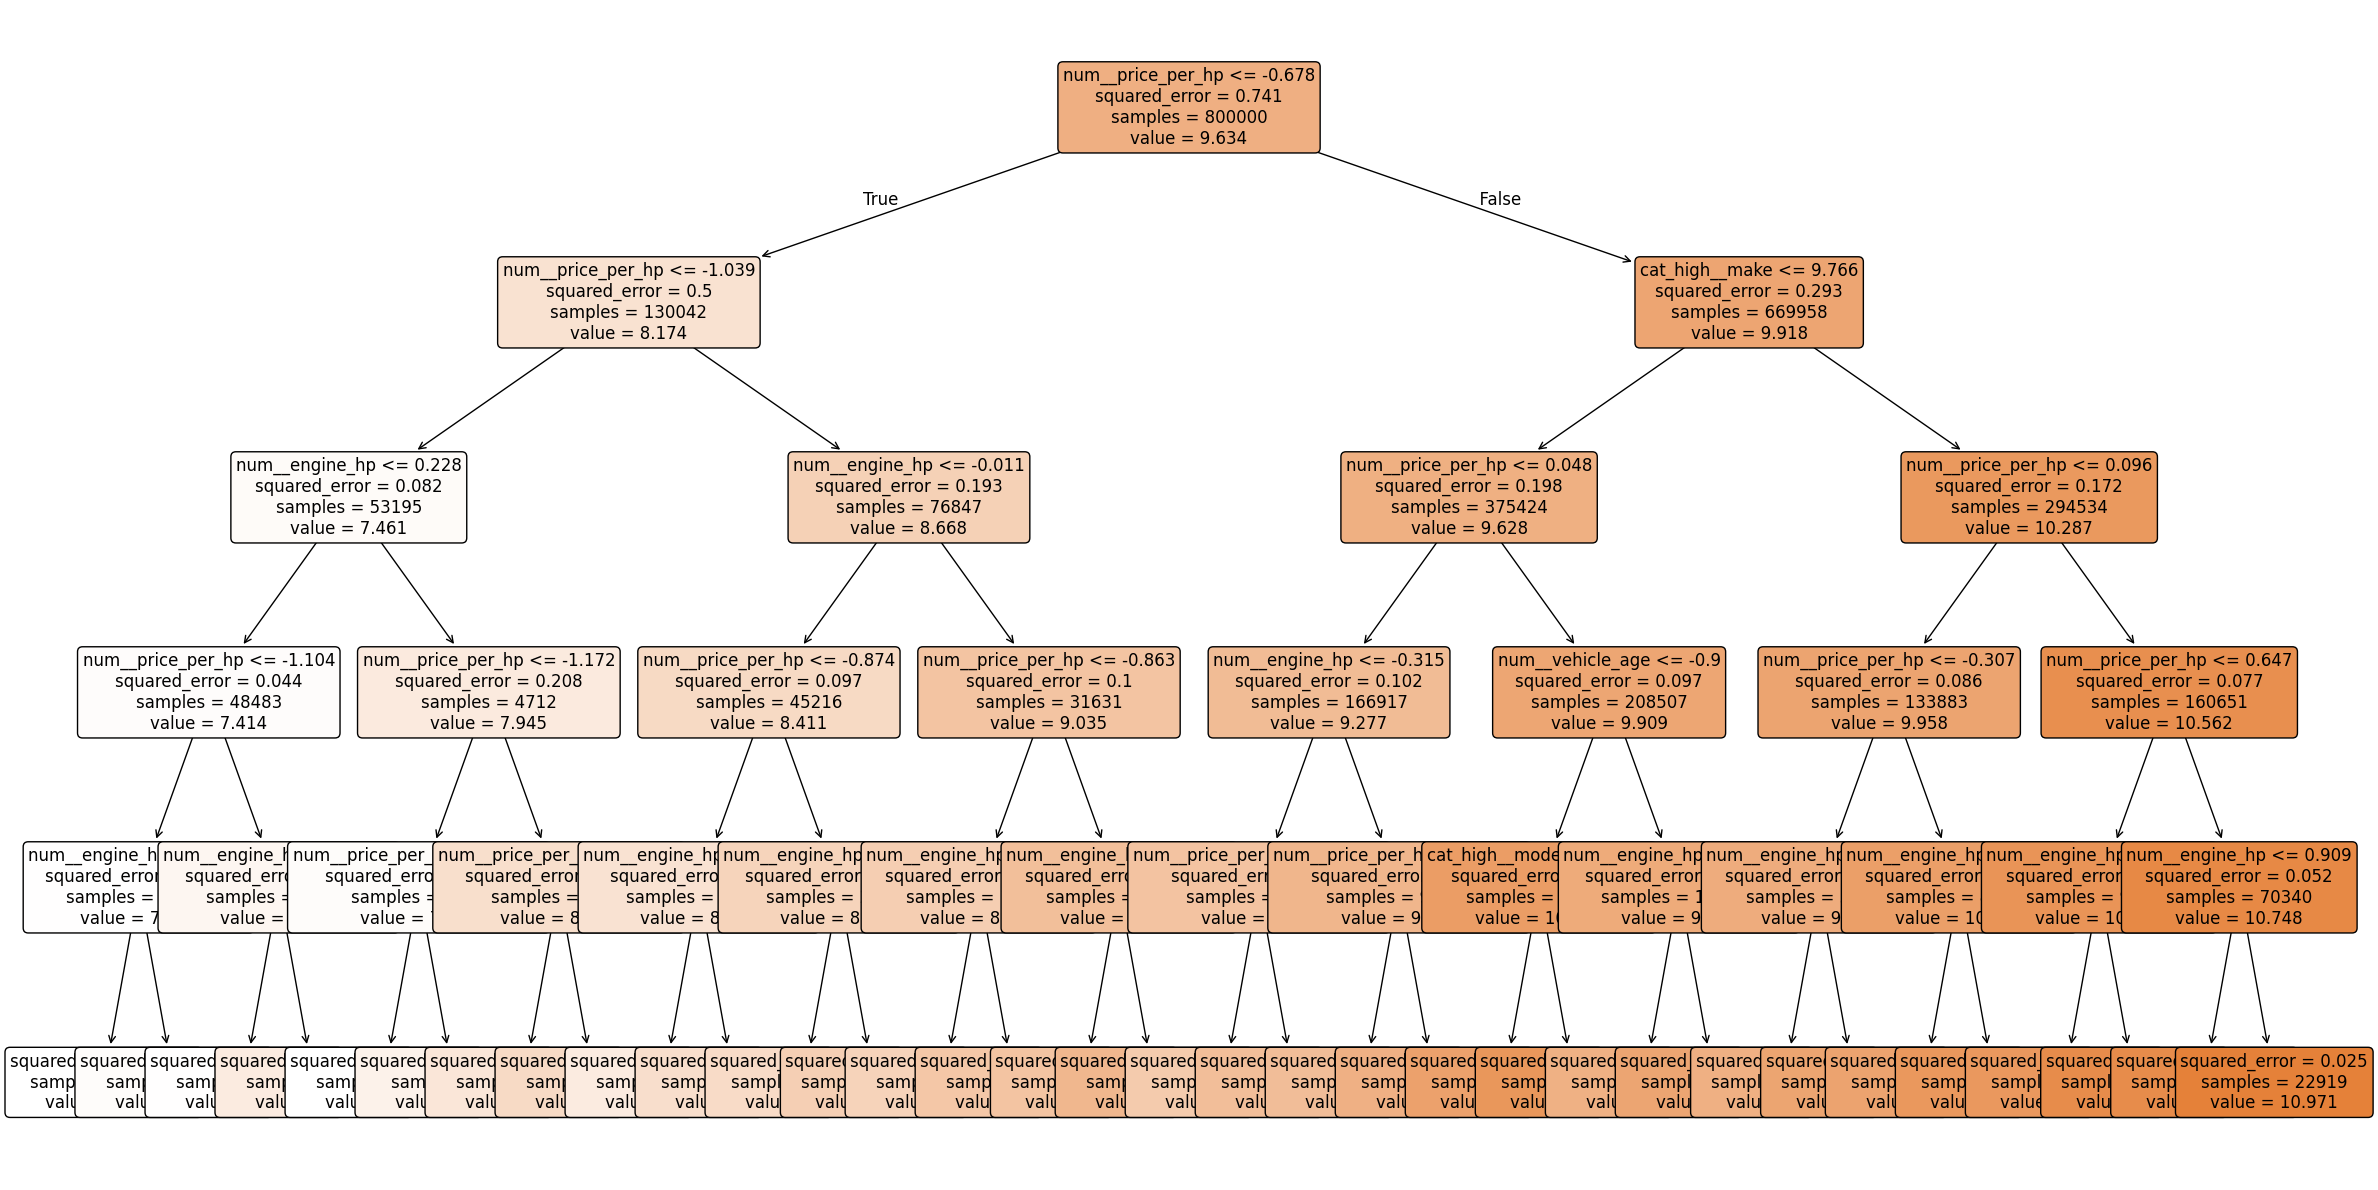

In [45]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))
plot_tree(
    fitted_dt_model,
    filled=True,
    feature_names=feature_names,
    fontsize=12,           
    rounded=True           
)
plt.tight_layout()         
plt.show()

2025-09-19 16:00:58,805 - INFO - Reg plot for decision tree predictions


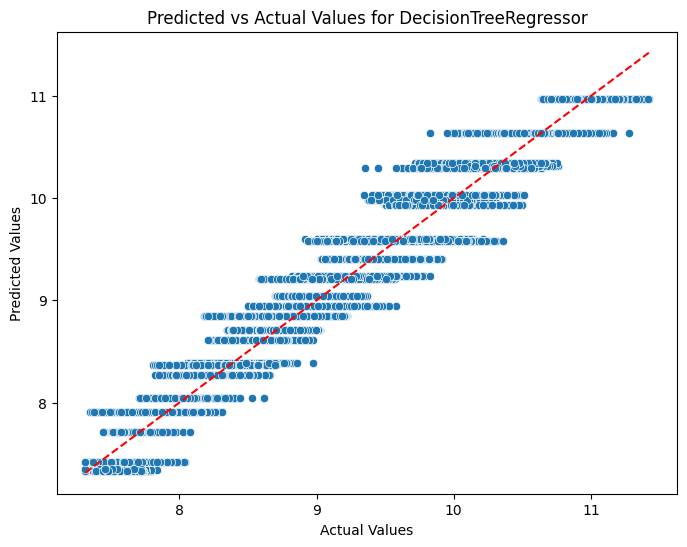

In [41]:
log_info("Reg plot for decision tree predictions")
reg_graph(dt_pipeline, X_test, y_test)

## Support Vector Regressor

In [ ]:
from sklearn.svm import SVR

log_info("Support Vector Regressor...")
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svr_pipeline = build_pipeline(preprocessor, svr_model)

2025-09-19 16:08:55,653 - INFO - Support Vector Regressor...


In [ ]:
log_info("Training and saving the SVR model...")
train_and_save_model(svr_pipeline, X_train, y_train, model_path="../models/svr_model.pkl")

2025-09-19 16:09:13,942 - INFO - Training and saving the SVR model...


- the execution is not done as it took 145 mins